Loaded 106 covariance states on SPD(32).
Merged atlas table saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/ehresmann_connection_atlas_v2/ehresmann_epoch_label_table.csv
Loaded 13 source CSV files.
Column construction used pd.concat to avoid DataFrame fragmentation.
Base semantic manifold built.
Base explained ratio: [0.3132 0.1822 0.0957]
Fiber covariance tangent space built.
Fiber explained ratio: [0.5657 0.0731 0.0487 0.0425 0.031  0.0279 0.0258 0.022 ]


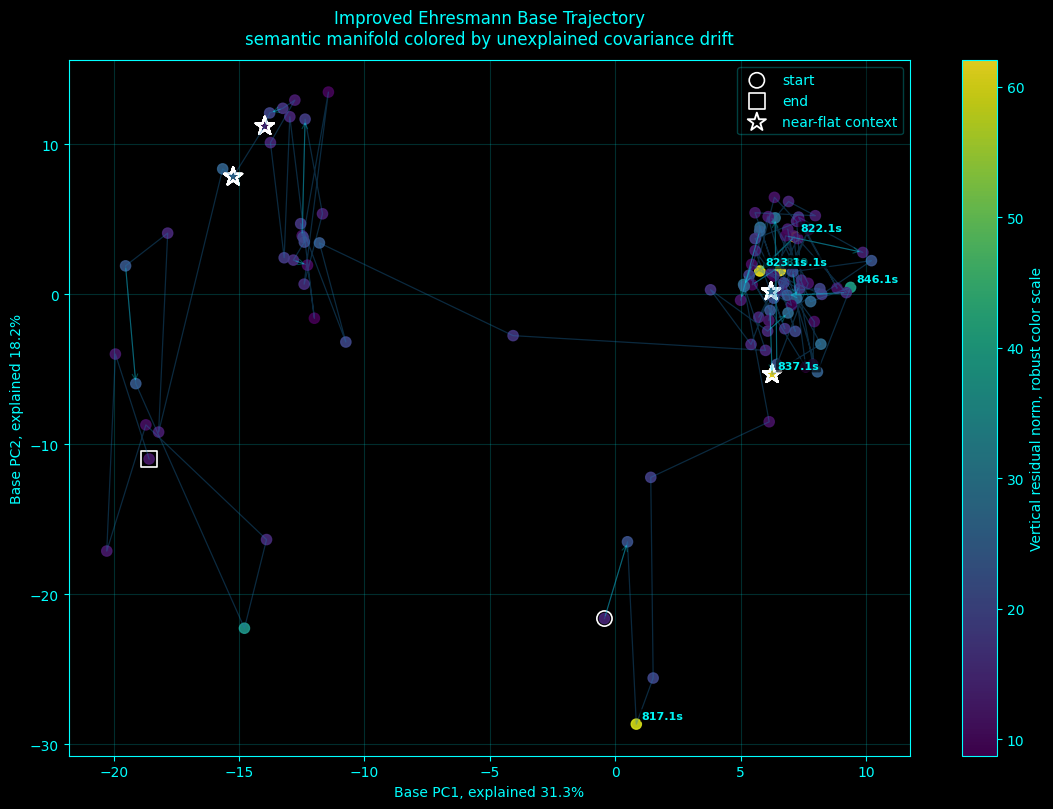

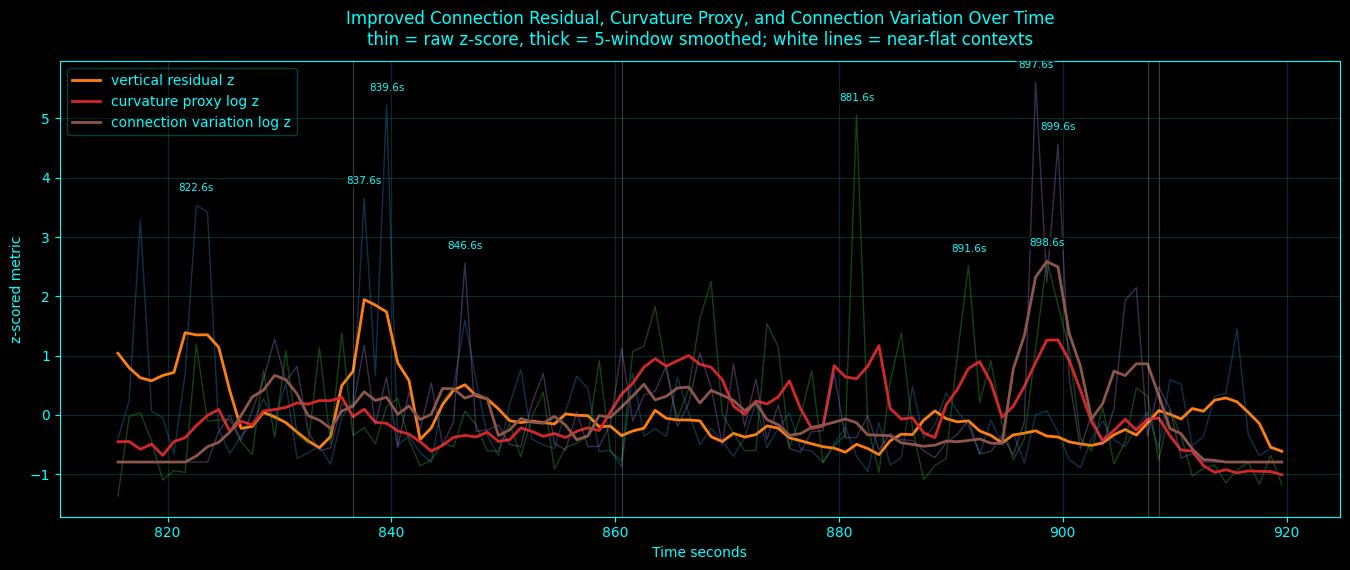

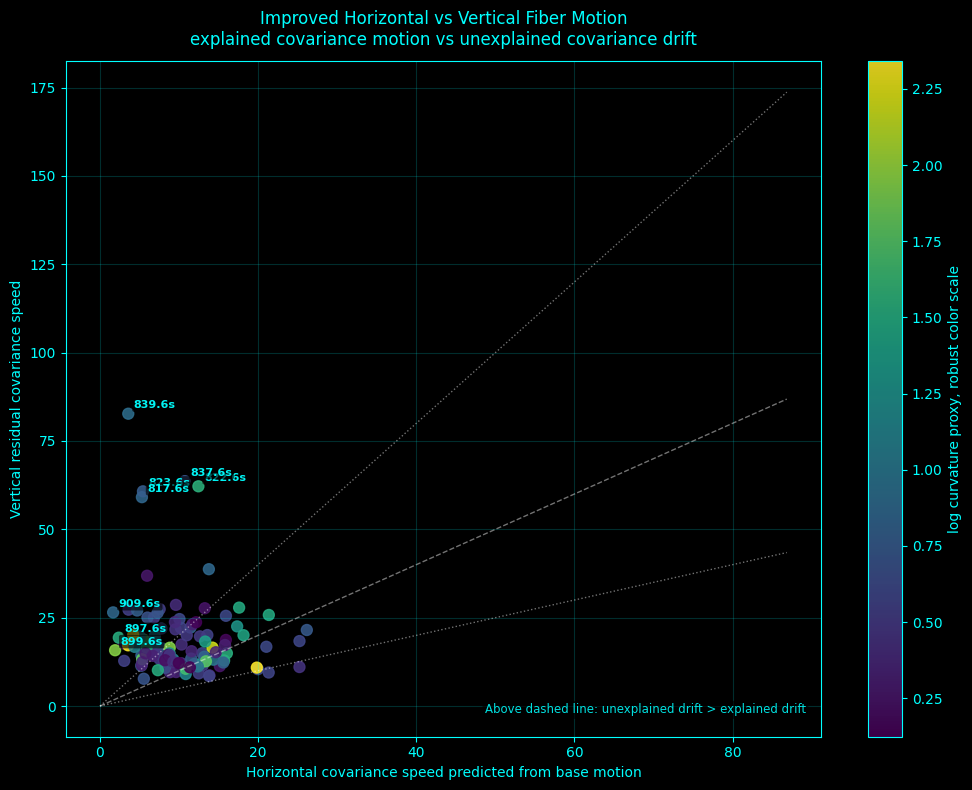

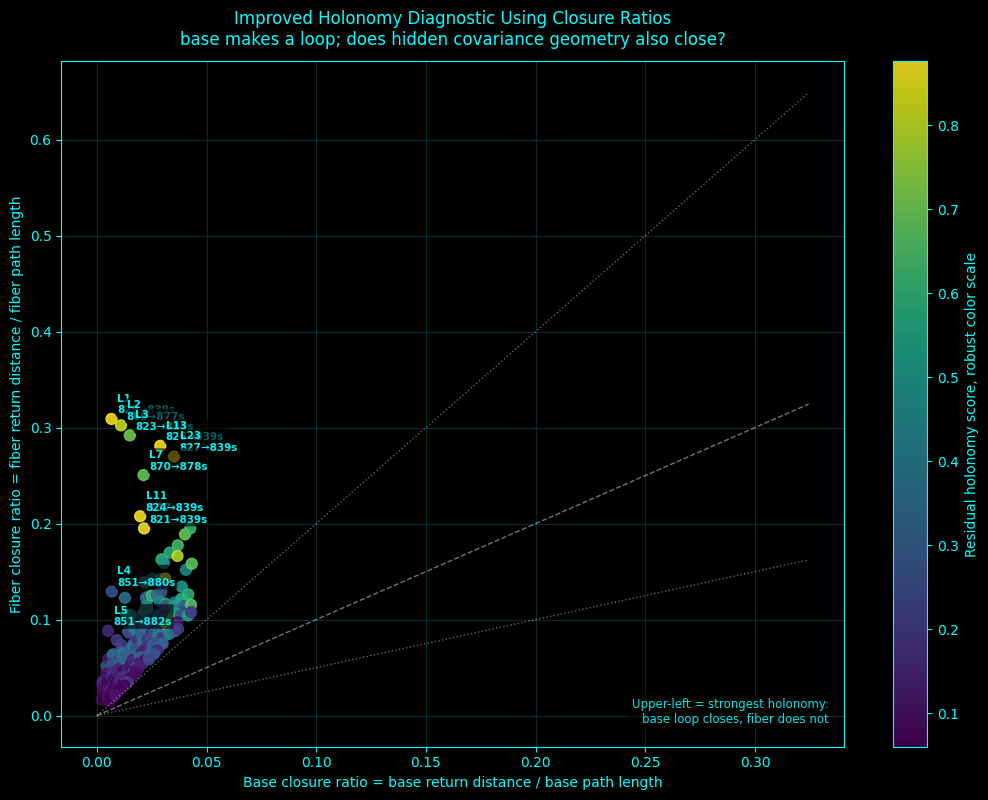

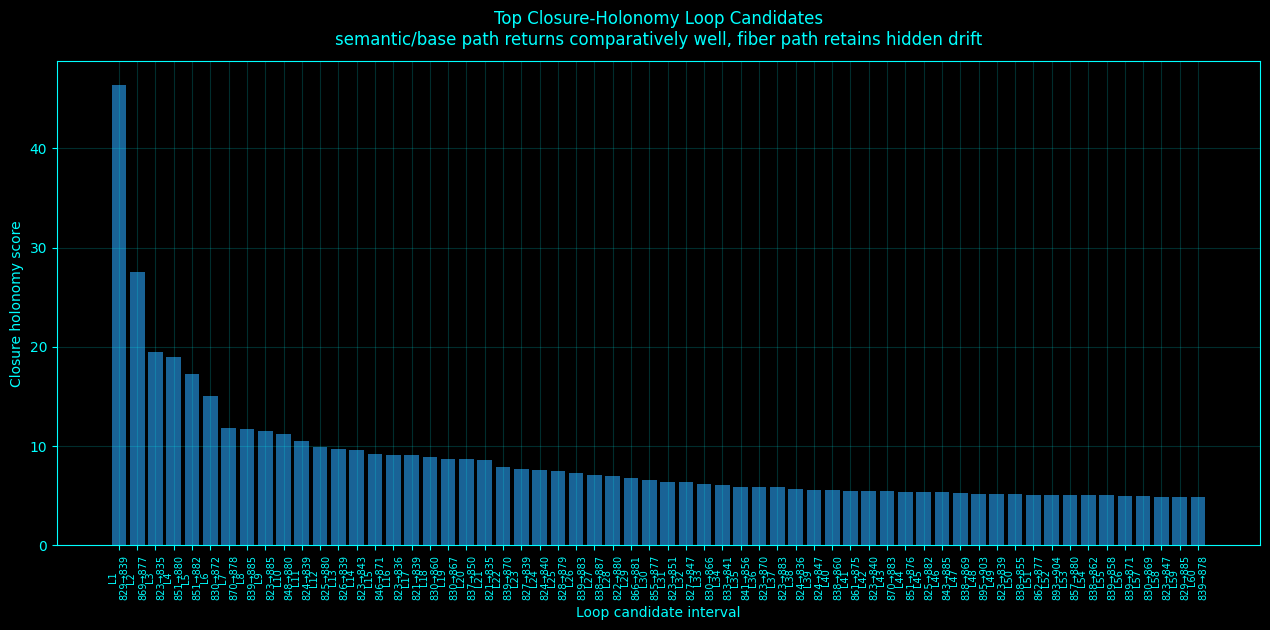

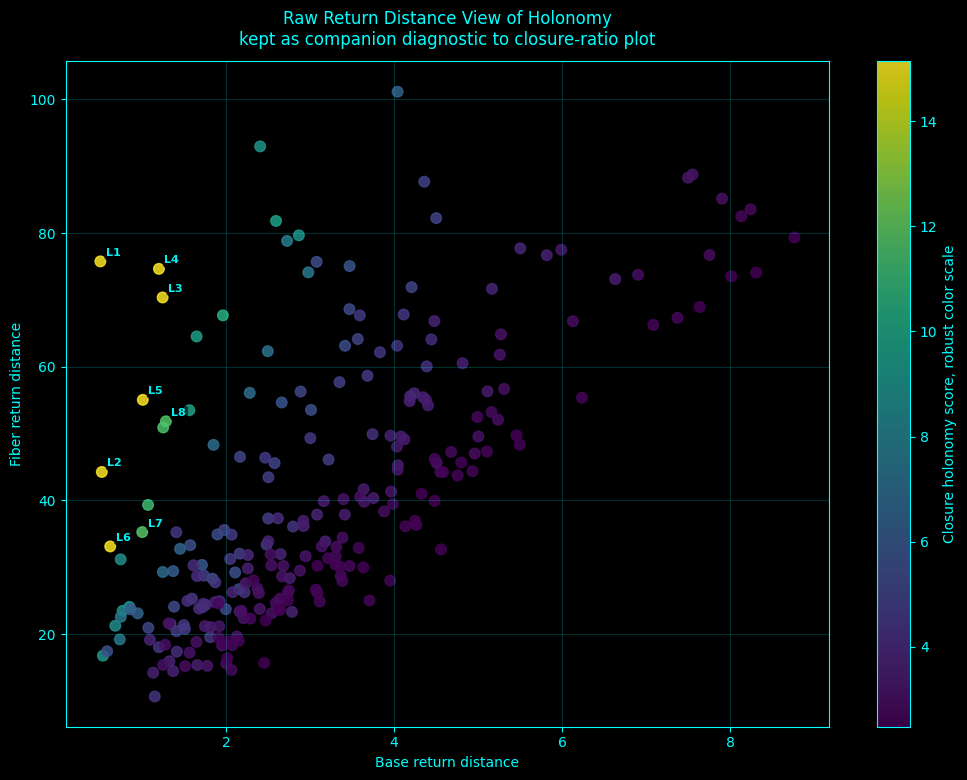

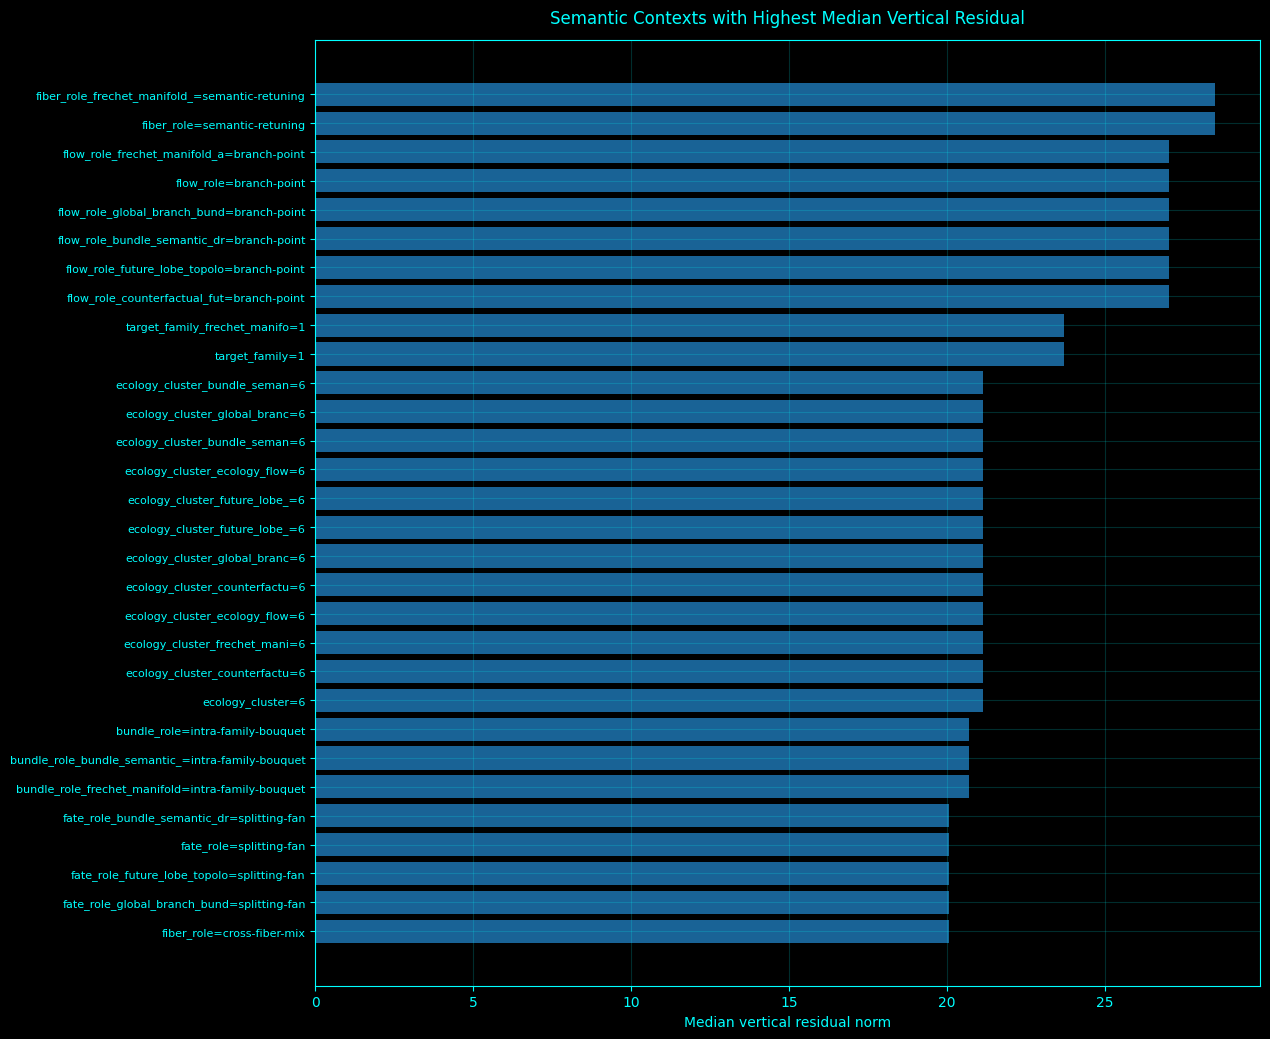

Source registry saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/ehresmann_connection_atlas_v2/ehresmann_source_registry.csv
Merged label table saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/ehresmann_connection_atlas_v2/ehresmann_epoch_label_table.csv
Connection metrics saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/ehresmann_connection_atlas_v2/connection_metrics_over_time.csv
Transport edges saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/ehresmann_connection_atlas_v2/connection_transport_edges.csv
Holonomy candidates saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/ehresmann_connection_atlas_v2/holonomy_loop_candidates.csv
Near-flat connection context saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/ehresmann_connection_atlas_v2/near_flat_connection_context.csv
Top event summary saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/ehresmann_connection_atlas_v2/top_connection_ev

In [1]:
import os
import re
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

base_dir = globals().get("base_dir", "/home/a/projects/Complete-Neural-Signal-Analysis")
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "ehresmann_connection_atlas_v2")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

window_size_sec = 1.0
samples_per_window = int(window_size_sec * sampling_rate)

cov_reg = 1e-6
eps = 1e-12

base_dim = 3
fiber_dim = 8

ridge_lambda = 1e-3
local_window = 17
min_local_rows = 8

min_loop_gap = 8
max_loop_candidates = 250
top_loop_count = 60

BG = "black"
ACCENT = "cyan"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

def style_ax(ax, grid=True):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    if grid:
        ax.grid(True, alpha=0.18, color=ACCENT)
    else:
        ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def sanitize_key(s):
    s = str(s)
    s = re.sub(r"[^A-Za-z0-9_]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s[:96] if len(s) else "unnamed"

def short_str(x, max_len=40):
    s = str(x)
    return s if len(s) <= max_len else s[:max_len - 3] + "..."

def nearest_index(source_times, target_times):
    source_times = np.asarray(source_times, dtype=float)
    target_times = np.asarray(target_times, dtype=float)

    if len(source_times) == 0:
        raise ValueError("source_times is empty.")

    if len(source_times) == 1:
        return np.zeros(len(target_times), dtype=int)

    idx = np.searchsorted(source_times, target_times)
    idx = np.clip(idx, 1, len(source_times) - 1)

    left = idx - 1
    right = idx

    choose_right = np.abs(source_times[right] - target_times) < np.abs(source_times[left] - target_times)
    return np.where(choose_right, right, left)

def zscore_safe(x):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    good = np.isfinite(x)
    if not np.any(good):
        return out
    sd = np.nanstd(x[good])
    if not np.isfinite(sd) or sd < 1e-12:
        return out
    out[good] = (x[good] - np.nanmean(x[good])) / sd
    return out

def robust_fill_numeric_frame(df):
    df = df.copy()
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        if df[c].notna().any():
            df[c] = df[c].fillna(df[c].median())
        else:
            df[c] = 0.0
    return df

def standardize_matrix(X):
    X = np.asarray(X, dtype=float)
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    sd[~np.isfinite(sd)] = 1.0
    sd[sd < 1e-12] = 1.0
    Xs = (X - mu) / sd
    Xs[~np.isfinite(Xs)] = 0.0
    return Xs, mu.ravel(), sd.ravel()

def pca_svd(X, n_components=2):
    X = np.asarray(X, dtype=float)
    Xs, mu, sd = standardize_matrix(X)

    U, S, Vt = np.linalg.svd(Xs, full_matrices=False)
    k = min(n_components, Vt.shape[0])

    scores = U[:, :k] * S[:k]
    components = Vt[:k, :]
    explained = (S ** 2) / max(Xs.shape[0] - 1, 1)

    total = float(np.sum(explained))
    if total > 0:
        explained_ratio = explained[:k] / total
    else:
        explained_ratio = np.zeros(k)

    if k < n_components:
        scores = np.column_stack([scores, np.zeros((scores.shape[0], n_components - k))])
        components = np.vstack([components, np.zeros((n_components - k, Xs.shape[1]))])
        explained_ratio = np.concatenate([explained_ratio, np.zeros(n_components - k)])

    return scores, components, explained_ratio, mu, sd

def ridge_solve(X, Y, lam=1e-3):
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    p = X.shape[1]
    return np.linalg.solve(X.T @ X + lam * np.eye(p), X.T @ Y)

def moving_window_indices(i, n, width):
    half = width // 2
    a = max(0, i - half)
    b = min(n, i + half + 1)

    if b - a < width:
        if a == 0:
            b = min(n, width)
        elif b == n:
            a = max(0, n - width)

    return np.arange(a, b)

def annotate_top_points(ax, x, y, labels, scores, top_n=8, dx=4, dy=4, fontsize=8):
    x = np.asarray(x)
    y = np.asarray(y)
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels).astype(str)

    good = np.isfinite(x) & np.isfinite(y) & np.isfinite(scores)
    if not np.any(good):
        return

    idx_good = np.where(good)[0]
    order = idx_good[np.argsort(scores[good])[::-1]][:top_n]

    for i in order:
        ax.annotate(
            labels[i],
            xy=(x[i], y[i]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=fontsize,
            weight="bold",
            color=ACCENT,
            alpha=0.96,
            bbox=dict(
                facecolor=BG,
                edgecolor="none",
                alpha=0.62,
                boxstyle="round,pad=0.15",
            ),
            clip_on=True,
        )

def robust_scatter_limits(values, q_low=0.02, q_high=0.98):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if len(v) == 0:
        return None, None
    lo = float(np.quantile(v, q_low))
    hi = float(np.quantile(v, q_high))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return None, None
    return lo, hi

def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, floor=eps):
    vals = np.asarray(vals, dtype=float)
    vals[vals < floor] = floor
    return vals

def sqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w)
    return (V * np.sqrt(w)) @ V.T

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w)
    return (V * np.log(w)) @ V.T

def expm_sym(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    return (V * np.exp(w)) @ V.T

def riemannian_frechet_mean(covs, max_iter=64, tol=1e-8):
    covs = np.asarray(covs, dtype=float)
    n_mats, n, _ = covs.shape

    if n_mats == 1:
        return symmetrize(covs[0])

    G = symmetrize(np.mean(covs, axis=0))

    for _ in range(max_iter):
        G_sqrt = sqrtm_spd(G)
        G_invsqrt = invsqrtm_spd(G)

        tangent_sum = np.zeros((n, n), dtype=float)
        for C in covs:
            tangent_sum += logm_spd(G_invsqrt @ C @ G_invsqrt)

        tangent_mean = tangent_sum / n_mats
        update_norm = float(np.linalg.norm(tangent_mean, ord="fro"))

        if update_norm < tol:
            break

        G = symmetrize(G_sqrt @ expm_sym(tangent_mean) @ G_sqrt)

    return G

def log_map_spd(P, C):
    P_sqrt = sqrtm_spd(P)
    P_invsqrt = invsqrtm_spd(P)
    inner = P_invsqrt @ C @ P_invsqrt
    return symmetrize(P_sqrt @ logm_spd(inner) @ P_sqrt)

def affine_invariant_distance(A, B):
    Binv = invsqrtm_spd(B)
    L = logm_spd(Binv @ A @ Binv)
    return float(np.linalg.norm(L, ord="fro"))

def vectorize_symmetric(A):
    idx = np.triu_indices(A.shape[0])
    return symmetrize(A)[idx]

def ensure_time_channel_layout(EEG_data, n_channels_expected=32):
    EEG_data = np.asarray(EEG_data, dtype=float)

    if EEG_data.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got {EEG_data.shape}")

    if EEG_data.shape[1] == n_channels_expected:
        return EEG_data
    if EEG_data.shape[0] == n_channels_expected:
        return EEG_data.T

    if EEG_data.shape[0] > EEG_data.shape[1]:
        return EEG_data

    return EEG_data.T

def segment_data(EEG_data_tc, samples_per_window):
    total_samples, n_channels = EEG_data_tc.shape
    n_windows = total_samples // samples_per_window
    trimmed = EEG_data_tc[:n_windows * samples_per_window]
    segmented = trimmed.reshape(n_windows, samples_per_window, n_channels)
    return np.transpose(segmented, (0, 2, 1))

def compute_cov_matrices(segmented_data, reg=cov_reg):
    epochs, n_channels, n_time = segmented_data.shape
    X = segmented_data - np.mean(segmented_data, axis=2, keepdims=True)
    covs = np.matmul(X, np.transpose(X, (0, 2, 1))) / max(n_time - 1, 1)
    covs += reg * np.eye(n_channels)[None, :, :]
    return 0.5 * (covs + np.transpose(covs, (0, 2, 1)))

EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, n_channels_expected=32)
EEG_data = EEG_data[start_index:end_index, :]

segmented_EEG = segment_data(EEG_data, samples_per_window=samples_per_window)
covs = compute_cov_matrices(segmented_EEG, reg=cov_reg)

n_epochs = covs.shape[0]
epoch_index = np.arange(n_epochs)
epoch_start_time = start_time + epoch_index * window_size_sec
epoch_center_time = epoch_start_time + 0.5 * window_size_sec

epoch_df = pd.DataFrame({
    "epoch_index": epoch_index,
    "center_time_sec": epoch_center_time,
})

print(f"Loaded {n_epochs} covariance states on SPD({covs.shape[1]}).")

candidate_label_csvs = [
    os.path.join(base_dir, "results", "continuous_motif_field_v1", "continuous_motif_field.csv"),
    os.path.join(base_dir, "results", "motif_field_ecology_atlas_v1", "motif_field_with_ecology_labels.csv"),
    os.path.join(base_dir, "results", "ecology_flow_cartography_v1", "motif_field_with_flow_roles.csv"),
    os.path.join(base_dir, "results", "counterfactual_future_cones_v1", "motif_field_with_future_cones.csv"),
    os.path.join(base_dir, "results", "future_lobe_topology_atlas_v1", "motif_field_with_lobe_topology.csv"),
    os.path.join(base_dir, "results", "global_branch_bundle_atlas_v1", "motif_field_with_global_bundles.csv"),
    os.path.join(base_dir, "results", "bundle_semantic_drift_atlas_v1", "motif_field_with_bundle_semantic_fibers.csv"),
    os.path.join(base_dir, "results", "bundle_relabel_wave_atlas_v1", "bundle_relabel_phase_index.csv"),
    os.path.join(base_dir, "results", "lock_fracture_atlas_v1", "time_resolved_fracture_pressure.csv"),
    os.path.join(base_dir, "results", "semantic_hysteresis_atlas_v1", "window_hysteresis_metrics.csv"),
    os.path.join(base_dir, "results", "exit_family_atlas_v1", "late_exit_family_per_window.csv"),
    os.path.join(base_dir, "results", "launch_syntax_atlas_v2", "launch_syntax_per_event.csv"),
    os.path.join(base_dir, "results", "frechet_manifold_atlas_v1", "frechet_epoch_label_table.csv"),
]

near_flat_csvs = [
    os.path.join(base_dir, "results", "stable_episode_corridor_atlas_v1", "near_flat_episode_context.csv"),
    os.path.join(base_dir, "results", "global_branch_bundle_atlas_v1", "near_flat_global_bundle_context.csv"),
    os.path.join(base_dir, "results", "bundle_relabel_wave_atlas_v1", "near_flat_relabel_stage_context.csv"),
    os.path.join(base_dir, "results", "lock_fracture_atlas_v1", "near_flat_defect_context.csv"),
    os.path.join(base_dir, "results", "semantic_hysteresis_atlas_v1", "near_flat_hysteresis_context.csv"),
    os.path.join(base_dir, "results", "exit_family_atlas_v1", "near_flat_exit_family_context.csv"),
    os.path.join(base_dir, "results", "launch_syntax_atlas_v2", "near_flat_launch_syntax_context.csv"),
    os.path.join(base_dir, "results", "frechet_manifold_atlas_v1", "near_flat_frechet_context.csv"),
]

preferred_label_columns = [
    "motif_label",
    "dominant_motif",
    "soft_motif",
    "ecology_cluster",
    "ecology_name",
    "flow_role",
    "fate_role",
    "topology_name",
    "global_bundle",
    "bundle_role",
    "fiber_role",
    "relabel_stage",
    "fracture_role",
    "hysteresis_role",
    "exit_family",
    "target_family",
    "precursor_cluster",
    "syntax_motif",
    "launch_syntax",
]

semantic_numeric_name_hints = [
    "motif",
    "ecology",
    "flow",
    "fate",
    "topology",
    "bundle",
    "fiber",
    "future",
    "lobe",
    "branch",
    "hysteresis",
    "exit",
    "syntax",
    "launch",
    "relabel",
    "fracture",
    "drift",
    "entropy",
    "purity",
    "consensus",
    "dispersion",
    "speed",
    "pressure",
    "score",
    "radius",
    "density",
    "umap",
    "tsne",
    "mds",
    "pc",
    "coord",
    "x",
    "y",
]

merged = epoch_df.copy()
add_frames = []
source_registry = []
used_column_names = set(merged.columns)

for path in candidate_label_csvs:
    if not os.path.exists(path):
        continue

    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"Skipping unreadable CSV: {path} | {e}")
        continue

    time_col = None
    for c in ["center_time_sec", "time_sec", "event_time_sec", "fissure_time_sec", "near_flat_time_sec"]:
        if c in df.columns:
            time_col = c
            break

    if time_col is None:
        continue

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

    if len(df) == 0:
        continue

    idx = nearest_index(df[time_col].values, merged["center_time_sec"].values)

    used_cols = []

    for c in df.columns:
        if c == time_col:
            continue

        is_preferred_label = c in preferred_label_columns
        is_numeric = pd.api.types.is_numeric_dtype(df[c])
        hint_match = any(h in c.lower() for h in semantic_numeric_name_hints)

        if is_preferred_label or (is_numeric and hint_match):
            used_cols.append(c)

    used_cols = sorted(set(used_cols))

    if len(used_cols) == 0:
        continue

    stem = sanitize_key(os.path.basename(os.path.dirname(path)))
    frame_dict = {}

    for c in used_cols:
        new_c = c
        if new_c in used_column_names or new_c in frame_dict:
            new_c = f"{c}__{stem}"

        counter = 2
        base_new_c = new_c
        while new_c in used_column_names or new_c in frame_dict:
            new_c = f"{base_new_c}_{counter}"
            counter += 1

        frame_dict[new_c] = df[c].values[idx]

    if frame_dict:
        add_frames.append(pd.DataFrame(frame_dict, index=merged.index))
        used_column_names.update(frame_dict.keys())

    source_registry.append({
        "csv": path,
        "time_col": time_col,
        "n_rows": len(df),
        "used_columns": ",".join(used_cols),
        "added_columns": ",".join(frame_dict.keys()),
    })

if add_frames:
    merged = pd.concat([merged] + add_frames, axis=1).copy()
else:
    merged = merged.copy()

source_registry_df = pd.DataFrame(source_registry)
source_registry_csv = os.path.join(out_dir, "ehresmann_source_registry.csv")
source_registry_df.to_csv(source_registry_csv, index=False)

merged_csv = os.path.join(out_dir, "ehresmann_epoch_label_table.csv")
merged.to_csv(merged_csv, index=False)

print(f"Merged atlas table saved: {merged_csv}")
print(f"Loaded {len(source_registry_df)} source CSV files.")
print("Column construction used pd.concat to avoid DataFrame fragmentation.")

exclude_numeric_cols = {
    "epoch_index",
    "center_time_sec",
    "time_sec",
    "event_time_sec",
    "fissure_time_sec",
    "near_flat_time_sec",
}

numeric_candidates = []

for c in merged.columns:
    if c in exclude_numeric_cols:
        continue

    s = merged[c]

    if pd.api.types.is_numeric_dtype(s):
        nunique = s.dropna().nunique()
        if nunique >= 3:
            numeric_candidates.append(c)

if len(numeric_candidates) < 2:
    cat_cols = []

    for c in merged.columns:
        if c in exclude_numeric_cols:
            continue

        nunique = merged[c].dropna().nunique()
        if 2 <= nunique <= 20:
            cat_cols.append(c)

    if cat_cols:
        dummy_frames = []
        for c in cat_cols:
            dummy_frames.append(pd.get_dummies(merged[c].astype(str), prefix=sanitize_key(c), dummy_na=False))

        dummy_df = pd.concat(dummy_frames, axis=1).copy()
        merged = pd.concat([merged, dummy_df], axis=1).copy()
        numeric_candidates.extend(dummy_df.columns.tolist())

if len(numeric_candidates) < 2:
    time_feature_df = pd.DataFrame({
        "time_base_0": zscore_safe(merged["center_time_sec"].values),
        "time_base_1": np.sin(2 * np.pi * zscore_safe(merged["center_time_sec"].values)),
        "time_base_2": np.cos(2 * np.pi * zscore_safe(merged["center_time_sec"].values)),
    }, index=merged.index)

    merged = pd.concat([merged, time_feature_df], axis=1).copy()
    numeric_candidates = ["time_base_0", "time_base_1", "time_base_2"]

base_feature_df = robust_fill_numeric_frame(merged[numeric_candidates])
base_raw = base_feature_df.values.astype(float)

B, base_components, base_explained, base_mu, base_sd = pca_svd(base_raw, n_components=base_dim)

base_coord_df = pd.DataFrame({
    "epoch_index": epoch_index,
    "center_time_sec": epoch_center_time,
})

for k in range(base_dim):
    base_coord_df[f"base_pc{k+1}"] = B[:, k]

base_coord_csv = os.path.join(out_dir, "base_semantic_coordinates.csv")
base_coord_df.to_csv(base_coord_csv, index=False)

base_feature_importance_rows = []

for k in range(base_dim):
    load = base_components[k]
    order = np.argsort(np.abs(load))[::-1][:25]

    for rank, j in enumerate(order, start=1):
        base_feature_importance_rows.append({
            "base_pc": k + 1,
            "rank": rank,
            "feature": numeric_candidates[j],
            "loading": float(load[j]),
            "abs_loading": float(abs(load[j])),
        })

base_feature_importance_df = pd.DataFrame(base_feature_importance_rows)
base_feature_importance_csv = os.path.join(out_dir, "base_feature_loadings_top.csv")
base_feature_importance_df.to_csv(base_feature_importance_csv, index=False)

print("Base semantic manifold built.")
print("Base explained ratio:", np.round(base_explained, 4))

global_mean_cov = riemannian_frechet_mean(covs)

tangent_vecs = []
dist_to_global = []

for C in covs:
    T = log_map_spd(global_mean_cov, C)
    tangent_vecs.append(vectorize_symmetric(T))
    dist_to_global.append(affine_invariant_distance(C, global_mean_cov))

tangent_vecs = np.asarray(tangent_vecs, dtype=float)
dist_to_global = np.asarray(dist_to_global, dtype=float)

F, fiber_components, fiber_explained, fiber_mu, fiber_sd = pca_svd(tangent_vecs, n_components=fiber_dim)

fiber_coord_df = pd.DataFrame({
    "epoch_index": epoch_index,
    "center_time_sec": epoch_center_time,
    "distance_to_global_cov_frechet_mean": dist_to_global,
})

for k in range(fiber_dim):
    fiber_coord_df[f"fiber_pc{k+1}"] = F[:, k]

fiber_coord_csv = os.path.join(out_dir, "fiber_covariance_tangent_coordinates.csv")
fiber_coord_df.to_csv(fiber_coord_csv, index=False)

print("Fiber covariance tangent space built.")
print("Fiber explained ratio:", np.round(fiber_explained, 4))

dt = window_size_sec

dB = np.diff(B, axis=0) / dt
dF = np.diff(F, axis=0) / dt

velocity_time = 0.5 * (epoch_center_time[:-1] + epoch_center_time[1:])
n_vel = dB.shape[0]

A_global = ridge_solve(dB, dF, lam=ridge_lambda)
dF_horizontal_global = dB @ A_global
dF_vertical_global = dF - dF_horizontal_global

A_local = np.zeros((n_vel, base_dim, fiber_dim), dtype=float)
dF_horizontal = np.zeros_like(dF)
dF_vertical = np.zeros_like(dF)

for i in range(n_vel):
    idx = moving_window_indices(i, n_vel, local_window)

    if len(idx) >= min_local_rows:
        try:
            A_i = ridge_solve(dB[idx], dF[idx], lam=ridge_lambda)
        except Exception:
            A_i = A_global.copy()
    else:
        A_i = A_global.copy()

    A_local[i] = A_i
    dF_horizontal[i] = dB[i] @ A_i
    dF_vertical[i] = dF[i] - dF_horizontal[i]

base_speed = np.linalg.norm(dB, axis=1)
fiber_speed = np.linalg.norm(dF, axis=1)
horizontal_speed = np.linalg.norm(dF_horizontal, axis=1)
vertical_residual_norm = np.linalg.norm(dF_vertical, axis=1)

parallel_transport_error = vertical_residual_norm / (fiber_speed + eps)
horizontal_fraction = horizontal_speed / (fiber_speed + horizontal_speed + eps)
vertical_fraction = vertical_residual_norm / (fiber_speed + horizontal_speed + vertical_residual_norm + eps)
vertical_to_horizontal_ratio = vertical_residual_norm / (horizontal_speed + eps)

connection_norm = np.linalg.norm(A_local.reshape(n_vel, -1), axis=1)

connection_variation = np.zeros(n_vel, dtype=float)
curvature_proxy = np.zeros(n_vel, dtype=float)
base_turn_area = np.zeros(n_vel, dtype=float)
horizontal_turn_norm = np.zeros(n_vel, dtype=float)

for i in range(1, n_vel):
    connection_variation[i] = np.linalg.norm(A_local[i] - A_local[i - 1], ord="fro") / (np.linalg.norm(dB[i]) + eps)

    u = dB[i - 1]
    v = dB[i]

    wedge_sq = max(float(np.dot(u, u) * np.dot(v, v) - np.dot(u, v) ** 2), 0.0)
    base_turn_area[i] = math.sqrt(wedge_sq)

    horizontal_turn_norm[i] = np.linalg.norm(dF_horizontal[i] - dF_horizontal[i - 1])
    curvature_proxy[i] = horizontal_turn_norm[i] / (base_turn_area[i] + eps)

curvature_proxy_log = np.log1p(curvature_proxy)
connection_variation_log = np.log1p(connection_variation)

connection_df = pd.DataFrame({
    "edge_index": np.arange(n_vel),
    "start_epoch_index": np.arange(n_vel),
    "end_epoch_index": np.arange(1, n_epochs),
    "center_time_sec": velocity_time,
    "start_time_sec": epoch_center_time[:-1],
    "end_time_sec": epoch_center_time[1:],
    "base_speed": base_speed,
    "fiber_speed": fiber_speed,
    "horizontal_speed": horizontal_speed,
    "vertical_residual_norm": vertical_residual_norm,
    "parallel_transport_error": parallel_transport_error,
    "horizontal_fraction": horizontal_fraction,
    "vertical_fraction": vertical_fraction,
    "vertical_to_horizontal_ratio": vertical_to_horizontal_ratio,
    "connection_norm": connection_norm,
    "connection_variation": connection_variation,
    "connection_variation_log": connection_variation_log,
    "base_turn_area": base_turn_area,
    "horizontal_turn_norm": horizontal_turn_norm,
    "curvature_proxy": curvature_proxy,
    "curvature_proxy_log": curvature_proxy_log,
})

base_vel_cols = pd.DataFrame(
    {f"base_velocity_pc{k+1}": dB[:, k] for k in range(base_dim)},
    index=connection_df.index,
)

fiber_vel_cols = pd.DataFrame(
    {
        **{f"fiber_velocity_pc{k+1}": dF[:, k] for k in range(fiber_dim)},
        **{f"horizontal_fiber_velocity_pc{k+1}": dF_horizontal[:, k] for k in range(fiber_dim)},
        **{f"vertical_residual_pc{k+1}": dF_vertical[:, k] for k in range(fiber_dim)},
    },
    index=connection_df.index,
)

connection_df = pd.concat([connection_df, base_vel_cols, fiber_vel_cols], axis=1).copy()

label_context_cols = [
    c for c in merged.columns
    if c not in exclude_numeric_cols
    and (
        c in preferred_label_columns
        or any(c.startswith(prefix + "__") for prefix in preferred_label_columns)
    )
]

if label_context_cols:
    idx = nearest_index(merged["center_time_sec"].values, connection_df["center_time_sec"].values)
    label_context_df = merged[label_context_cols].iloc[idx].reset_index(drop=True)
    connection_df = pd.concat([connection_df.reset_index(drop=True), label_context_df], axis=1).copy()

connection_metrics_csv = os.path.join(out_dir, "connection_metrics_over_time.csv")
connection_df.to_csv(connection_metrics_csv, index=False)

transport_edges_df = connection_df[
    [
        "edge_index",
        "start_epoch_index",
        "end_epoch_index",
        "start_time_sec",
        "end_time_sec",
        "base_speed",
        "fiber_speed",
        "horizontal_speed",
        "vertical_residual_norm",
        "parallel_transport_error",
        "vertical_to_horizontal_ratio",
        "connection_norm",
        "connection_variation_log",
        "curvature_proxy_log",
    ]
].copy()

transport_edges_csv = os.path.join(out_dir, "connection_transport_edges.csv")
transport_edges_df.to_csv(transport_edges_csv, index=False)

np.savez_compressed(
    os.path.join(out_dir, "local_connection_matrices.npz"),
    A_global=A_global,
    A_local=A_local,
    base_components=base_components,
    base_explained=base_explained,
    base_mu=base_mu,
    base_sd=base_sd,
    fiber_components=fiber_components,
    fiber_explained=fiber_explained,
    fiber_mu=fiber_mu,
    fiber_sd=fiber_sd,
    global_mean_cov=global_mean_cov,
)

pair_rows = []

for i in range(n_epochs):
    for j in range(i + min_loop_gap, n_epochs):
        base_return_distance = float(np.linalg.norm(B[j] - B[i]))
        fiber_return_distance = float(np.linalg.norm(F[j] - F[i]))

        base_steps = np.linalg.norm(np.diff(B[i:j + 1], axis=0), axis=1)
        fiber_steps = np.linalg.norm(np.diff(F[i:j + 1], axis=0), axis=1)

        path_base_length = float(np.sum(base_steps))
        path_fiber_length = float(np.sum(fiber_steps))

        residual_segment = dF_vertical[i:j]
        horizontal_segment = dF_horizontal[i:j]

        vertical_integral_vec = np.sum(residual_segment, axis=0) * dt
        horizontal_integral_vec = np.sum(horizontal_segment, axis=0) * dt

        vertical_integral_norm = float(np.linalg.norm(vertical_integral_vec))
        horizontal_integral_norm = float(np.linalg.norm(horizontal_integral_vec))

        mean_curvature_log = float(np.nanmean(curvature_proxy_log[i:j])) if j > i else np.nan
        mean_connection_error = float(np.nanmean(parallel_transport_error[i:j])) if j > i else np.nan

        base_closure_ratio = base_return_distance / (path_base_length + eps)
        fiber_closure_ratio = fiber_return_distance / (path_fiber_length + eps)

        holonomy_score = fiber_return_distance / (base_return_distance + 0.10 * path_base_length + eps)
        residual_holonomy_score = vertical_integral_norm / (path_base_length + eps)
        closure_holonomy_score = fiber_closure_ratio / (base_closure_ratio + eps)

        pair_rows.append({
            "start_epoch_index": i,
            "end_epoch_index": j,
            "start_time_sec": float(epoch_center_time[i]),
            "end_time_sec": float(epoch_center_time[j]),
            "duration_sec": float(epoch_center_time[j] - epoch_center_time[i]),
            "base_return_distance": base_return_distance,
            "fiber_return_distance": fiber_return_distance,
            "base_path_length": path_base_length,
            "fiber_path_length": path_fiber_length,
            "base_closure_ratio": base_closure_ratio,
            "fiber_closure_ratio": fiber_closure_ratio,
            "vertical_integral_norm": vertical_integral_norm,
            "horizontal_integral_norm": horizontal_integral_norm,
            "mean_curvature_proxy_log": mean_curvature_log,
            "mean_parallel_transport_error": mean_connection_error,
            "holonomy_score": holonomy_score,
            "residual_holonomy_score": residual_holonomy_score,
            "closure_holonomy_score": closure_holonomy_score,
        })

loop_df_all = pd.DataFrame(pair_rows)

if len(loop_df_all):
    close_threshold = loop_df_all["base_closure_ratio"].quantile(0.25)

    loop_df = (
        loop_df_all[loop_df_all["base_closure_ratio"] <= close_threshold]
        .sort_values(
            ["closure_holonomy_score", "residual_holonomy_score", "fiber_return_distance"],
            ascending=[False, False, False],
        )
        .head(max_loop_candidates)
        .reset_index(drop=True)
    )

    loop_df["loop_rank"] = np.arange(1, len(loop_df) + 1)
else:
    loop_df = pd.DataFrame()

holonomy_csv = os.path.join(out_dir, "holonomy_loop_candidates.csv")
loop_df.to_csv(holonomy_csv, index=False)

near_rows = []

for path in near_flat_csvs:
    if not os.path.exists(path):
        continue

    try:
        nf = pd.read_csv(path)
    except Exception:
        continue

    time_col = None
    for c in ["center_time_sec", "time_sec", "event_time_sec", "near_flat_time_sec"]:
        if c in nf.columns:
            time_col = c
            break

    if time_col is None:
        continue

    nf = nf.dropna(subset=[time_col]).copy()

    if len(nf) == 0:
        continue

    idxs = nearest_index(connection_df["center_time_sec"].values, nf[time_col].values)

    for row_i, edge_i in enumerate(idxs):
        src_time = float(nf[time_col].values[row_i])
        r = connection_df.iloc[int(edge_i)]

        near_rows.append({
            "source_csv": path,
            "source_row": int(row_i),
            "event_time_sec": src_time,
            "nearest_edge_index": int(r["edge_index"]),
            "nearest_connection_time_sec": float(r["center_time_sec"]),
            "base_speed": float(r["base_speed"]),
            "fiber_speed": float(r["fiber_speed"]),
            "horizontal_speed": float(r["horizontal_speed"]),
            "vertical_residual_norm": float(r["vertical_residual_norm"]),
            "vertical_to_horizontal_ratio": float(r["vertical_to_horizontal_ratio"]),
            "parallel_transport_error": float(r["parallel_transport_error"]),
            "connection_norm": float(r["connection_norm"]),
            "connection_variation_log": float(r["connection_variation_log"]),
            "curvature_proxy_log": float(r["curvature_proxy_log"]),
        })

near_connection_df = pd.DataFrame(near_rows)
near_connection_csv = os.path.join(out_dir, "near_flat_connection_context.csv")
near_connection_df.to_csv(near_connection_csv, index=False)

event_rows = []

top_event_specs = [
    ("vertical_residual", "vertical_residual_norm"),
    ("curvature_proxy", "curvature_proxy_log"),
    ("connection_variation", "connection_variation_log"),
    ("vertical_to_horizontal", "vertical_to_horizontal_ratio"),
    ("parallel_transport_error", "parallel_transport_error"),
]

for event_type, col in top_event_specs:
    top = connection_df.sort_values(col, ascending=False).head(12)
    for rank, (_, r) in enumerate(top.iterrows(), start=1):
        event_rows.append({
            "event_type": event_type,
            "rank": rank,
            "edge_index": int(r["edge_index"]),
            "center_time_sec": float(r["center_time_sec"]),
            "metric_column": col,
            "metric_value": float(r[col]),
            "base_speed": float(r["base_speed"]),
            "fiber_speed": float(r["fiber_speed"]),
            "horizontal_speed": float(r["horizontal_speed"]),
            "vertical_residual_norm": float(r["vertical_residual_norm"]),
            "curvature_proxy_log": float(r["curvature_proxy_log"]),
            "connection_variation_log": float(r["connection_variation_log"]),
            "vertical_to_horizontal_ratio": float(r["vertical_to_horizontal_ratio"]),
        })

event_summary_df = pd.DataFrame(event_rows)
event_summary_csv = os.path.join(out_dir, "top_connection_event_summary.csv")
event_summary_df.to_csv(event_summary_csv, index=False)

near_times = []
if len(near_connection_df):
    near_times = near_connection_df["nearest_connection_time_sec"].dropna().unique().tolist()

top_resid_idx = np.argsort(vertical_residual_norm)[::-1][:8]
top_curv_idx = np.argsort(curvature_proxy_log)[::-1][:8]
top_var_idx = np.argsort(connection_variation_log)[::-1][:8]
top_ratio_idx = np.argsort(vertical_to_horizontal_ratio)[::-1][:8]

fig, ax = plt.subplots(figsize=(11.4, 8.2))

color_values = np.r_[vertical_residual_norm, vertical_residual_norm[-1] if len(vertical_residual_norm) else 0]
vmin, vmax = robust_scatter_limits(color_values, 0.02, 0.98)

sc = ax.scatter(
    B[:, 0],
    B[:, 1],
    c=color_values,
    s=54,
    alpha=0.88,
    vmin=vmin,
    vmax=vmax,
)

ax.plot(B[:, 0], B[:, 1], linewidth=0.9, alpha=0.35)

if n_epochs >= 2:
    ax.scatter(B[0, 0], B[0, 1], s=120, marker="o", facecolors="none", edgecolors="white", linewidths=1.2, label="start")
    ax.scatter(B[-1, 0], B[-1, 1], s=140, marker="s", facecolors="none", edgecolors="white", linewidths=1.2, label="end")

    step = max(1, n_epochs // 14)
    for i in range(0, n_epochs - 1, step):
        ax.annotate(
            "",
            xy=(B[i + 1, 0], B[i + 1, 1]),
            xytext=(B[i, 0], B[i, 1]),
            arrowprops=dict(arrowstyle="->", color=ACCENT, alpha=0.28, lw=0.8),
        )

if len(near_connection_df):
    near_epoch_idx = nearest_index(epoch_center_time, near_connection_df["event_time_sec"].values)
    ax.scatter(
        B[near_epoch_idx, 0],
        B[near_epoch_idx, 1],
        s=190,
        marker="*",
        facecolors="none",
        edgecolors="white",
        linewidths=1.35,
        label="near-flat context",
    )

point_labels = np.array([f"{t:.1f}s" for t in epoch_center_time])
annotate_scores = np.r_[vertical_residual_norm, vertical_residual_norm[-1] if len(vertical_residual_norm) else 0]
annotate_top_points(ax, B[:, 0], B[:, 1], point_labels, annotate_scores, top_n=6, fontsize=8)

style_ax(ax)
ax.set_title(
    "Improved Ehresmann Base Trajectory\nsemantic manifold colored by unexplained covariance drift",
    pad=12,
)
ax.set_xlabel(f"Base PC1, explained {100 * base_explained[0]:.1f}%")
ax.set_ylabel(f"Base PC2, explained {100 * base_explained[1]:.1f}%")

cbar = plt.colorbar(sc, ax=ax)
cbar.ax.tick_params(colors=ACCENT)
cbar.set_label("Vertical residual norm, robust color scale", color=ACCENT)

ax.legend(framealpha=0.25, loc="best")

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "improved_base_trajectory_vertical_residual.png"), dpi=260, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(13.6, 5.8))

series_specs = [
    ("vertical residual z", "vertical_residual_norm"),
    ("curvature proxy log z", "curvature_proxy_log"),
    ("connection variation log z", "connection_variation_log"),
]

for label, col in series_specs:
    y = zscore_safe(connection_df[col].values)
    smooth = pd.Series(y).rolling(5, center=True, min_periods=1).mean().values

    ax.plot(connection_df["center_time_sec"], y, linewidth=1.0, alpha=0.42)
    ax.plot(connection_df["center_time_sec"], smooth, label=label, linewidth=2.0)

for t in near_times:
    ax.axvline(t, color="white", alpha=0.23, linewidth=0.85)

def annotate_series_peaks(col, color_label, top_n=4, y_offset=0.18):
    y = zscore_safe(connection_df[col].values)
    order = np.argsort(y)[::-1][:top_n]
    for i in order:
        ax.annotate(
            f"{connection_df['center_time_sec'].iloc[i]:.1f}s",
            xy=(connection_df["center_time_sec"].iloc[i], y[i]),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=7.5,
            color=ACCENT,
            bbox=dict(facecolor=BG, edgecolor="none", alpha=0.62, boxstyle="round,pad=0.14"),
            clip_on=True,
        )

annotate_series_peaks("vertical_residual_norm", "vertical", top_n=3)
annotate_series_peaks("curvature_proxy_log", "curvature", top_n=3)
annotate_series_peaks("connection_variation_log", "variation", top_n=3)

style_ax(ax)
ax.set_title(
    "Improved Connection Residual, Curvature Proxy, and Connection Variation Over Time\n"
    "thin = raw z-score, thick = 5-window smoothed; white lines = near-flat contexts",
    pad=12,
)
ax.set_xlabel("Time seconds")
ax.set_ylabel("z-scored metric")
ax.legend(framealpha=0.25, loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "improved_connection_metrics_over_time.png"), dpi=260, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10.3, 8.0))

color_values = connection_df["curvature_proxy_log"].values
vmin, vmax = robust_scatter_limits(color_values, 0.02, 0.98)

sc = ax.scatter(
    horizontal_speed,
    vertical_residual_norm,
    c=color_values,
    s=62,
    alpha=0.86,
    vmin=vmin,
    vmax=vmax,
)

max_axis = float(np.nanmax([np.nanmax(horizontal_speed), np.nanmax(vertical_residual_norm)]))
if np.isfinite(max_axis) and max_axis > 0:
    xs = np.linspace(0, max_axis * 1.05, 200)

    ax.plot(xs, xs, linestyle="--", color="white", alpha=0.45, linewidth=1.0)
    ax.plot(xs, 2.0 * xs, linestyle=":", color="white", alpha=0.45, linewidth=1.0)
    ax.plot(xs, 0.5 * xs, linestyle=":", color="white", alpha=0.45, linewidth=1.0)

    ax.text(
        0.98,
        0.03,
        "Above dashed line: unexplained drift > explained drift",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8.5,
        alpha=0.88,
        bbox=dict(facecolor=BG, edgecolor="none", alpha=0.62, boxstyle="round,pad=0.20"),
    )

labels = np.array([f"{t:.1f}s" for t in connection_df["center_time_sec"].values])
score = zscore_safe(vertical_residual_norm) + zscore_safe(vertical_to_horizontal_ratio) + 0.5 * zscore_safe(curvature_proxy_log)
annotate_top_points(ax, horizontal_speed, vertical_residual_norm, labels, score, top_n=8, fontsize=8)

style_ax(ax)
ax.set_title(
    "Improved Horizontal vs Vertical Fiber Motion\nexplained covariance motion vs unexplained covariance drift",
    pad=12,
)
ax.set_xlabel("Horizontal covariance speed predicted from base motion")
ax.set_ylabel("Vertical residual covariance speed")

cbar = plt.colorbar(sc, ax=ax)
cbar.ax.tick_params(colors=ACCENT)
cbar.set_label("log curvature proxy, robust color scale", color=ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "improved_horizontal_vs_vertical_fiber_motion.png"), dpi=260, bbox_inches="tight")
plt.show()

if len(loop_df):
    plot_loop_df = loop_df.copy()

    fig, ax = plt.subplots(figsize=(10.6, 8.1))

    color_values = plot_loop_df["residual_holonomy_score"].values
    vmin, vmax = robust_scatter_limits(color_values, 0.02, 0.98)

    sc = ax.scatter(
        plot_loop_df["base_closure_ratio"],
        plot_loop_df["fiber_closure_ratio"],
        c=color_values,
        s=62,
        alpha=0.86,
        vmin=vmin,
        vmax=vmax,
    )

    max_axis = float(np.nanmax([plot_loop_df["base_closure_ratio"].max(), plot_loop_df["fiber_closure_ratio"].max()]))
    if np.isfinite(max_axis) and max_axis > 0:
        xs = np.linspace(0, max_axis * 1.05, 200)
        ax.plot(xs, xs, linestyle="--", color="white", alpha=0.45, linewidth=1.0)
        ax.plot(xs, 2.0 * xs, linestyle=":", color="white", alpha=0.40, linewidth=1.0)
        ax.plot(xs, 0.5 * xs, linestyle=":", color="white", alpha=0.40, linewidth=1.0)

    labels = np.array([
        f"L{int(r.loop_rank)}\n{r.start_time_sec:.0f}→{r.end_time_sec:.0f}s"
        for _, r in plot_loop_df.iterrows()
    ])

    score = (
        zscore_safe(plot_loop_df["closure_holonomy_score"].values)
        + zscore_safe(plot_loop_df["residual_holonomy_score"].values)
        - 0.5 * zscore_safe(plot_loop_df["base_closure_ratio"].values)
    )

    annotate_top_points(
        ax,
        plot_loop_df["base_closure_ratio"].values,
        plot_loop_df["fiber_closure_ratio"].values,
        labels,
        score,
        top_n=10,
        fontsize=7.5,
    )

    style_ax(ax)
    ax.set_title(
        "Improved Holonomy Diagnostic Using Closure Ratios\n"
        "base makes a loop; does hidden covariance geometry also close?",
        pad=12,
    )
    ax.set_xlabel("Base closure ratio = base return distance / base path length")
    ax.set_ylabel("Fiber closure ratio = fiber return distance / fiber path length")

    ax.text(
        0.98,
        0.03,
        "Upper-left = strongest holonomy:\nbase loop closes, fiber does not",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8.5,
        alpha=0.90,
        bbox=dict(facecolor=BG, edgecolor="none", alpha=0.62, boxstyle="round,pad=0.20"),
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.ax.tick_params(colors=ACCENT)
    cbar.set_label("Residual holonomy score, robust color scale", color=ACCENT)

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "improved_holonomy_closure_ratio_diagnostic.png"), dpi=260, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(12.8, 6.4))

    top_loop_df = loop_df.head(min(top_loop_count, len(loop_df))).copy()

    labels = [
        f"L{int(r.loop_rank)}\n{int(r.start_time_sec)}→{int(r.end_time_sec)}"
        for _, r in top_loop_df.iterrows()
    ]

    ax.bar(
        np.arange(len(top_loop_df)),
        top_loop_df["closure_holonomy_score"].values,
        alpha=0.84,
    )

    ax.set_xticks(np.arange(len(top_loop_df)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)

    style_ax(ax)
    ax.set_title(
        "Top Closure-Holonomy Loop Candidates\n"
        "semantic/base path returns comparatively well, fiber path retains hidden drift",
        pad=12,
    )
    ax.set_xlabel("Loop candidate interval")
    ax.set_ylabel("Closure holonomy score")

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "improved_top_closure_holonomy_loop_candidates.png"), dpi=260, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(10.4, 7.9))

    color_values = plot_loop_df["closure_holonomy_score"].values
    vmin, vmax = robust_scatter_limits(color_values, 0.02, 0.98)

    sc = ax.scatter(
        plot_loop_df["base_return_distance"],
        plot_loop_df["fiber_return_distance"],
        c=color_values,
        s=58,
        alpha=0.84,
        vmin=vmin,
        vmax=vmax,
    )

    labels = np.array([
        f"L{int(r.loop_rank)}"
        for _, r in plot_loop_df.iterrows()
    ])

    score = zscore_safe(plot_loop_df["closure_holonomy_score"].values)
    annotate_top_points(
        ax,
        plot_loop_df["base_return_distance"].values,
        plot_loop_df["fiber_return_distance"].values,
        labels,
        score,
        top_n=8,
        fontsize=8,
    )

    style_ax(ax)
    ax.set_title(
        "Raw Return Distance View of Holonomy\n"
        "kept as companion diagnostic to closure-ratio plot",
        pad=12,
    )
    ax.set_xlabel("Base return distance")
    ax.set_ylabel("Fiber return distance")

    cbar = plt.colorbar(sc, ax=ax)
    cbar.ax.tick_params(colors=ACCENT)
    cbar.set_label("Closure holonomy score, robust color scale", color=ACCENT)

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "improved_holonomy_raw_return_distance_companion.png"), dpi=260, bbox_inches="tight")
    plt.show()

summary_metric_cols = [
    "base_speed",
    "fiber_speed",
    "horizontal_speed",
    "vertical_residual_norm",
    "vertical_to_horizontal_ratio",
    "parallel_transport_error",
    "curvature_proxy_log",
    "connection_variation_log",
]

possible_context_cols = [
    c for c in label_context_cols
    if c in connection_df.columns
    and connection_df[c].dropna().nunique() >= 2
    and connection_df[c].dropna().nunique() <= 20
]

context_summary_rows = []

for c in possible_context_cols:
    for value, sub in connection_df.groupby(c):
        if len(sub) < 3:
            continue

        row = {
            "context_column": c,
            "context_value": value,
            "n_edges": int(len(sub)),
        }

        for m in summary_metric_cols:
            row[f"median_{m}"] = float(np.nanmedian(sub[m].values))
            row[f"mean_{m}"] = float(np.nanmean(sub[m].values))

        context_summary_rows.append(row)

context_summary_df = pd.DataFrame(context_summary_rows)
context_summary_csv = os.path.join(out_dir, "connection_context_summary.csv")
context_summary_df.to_csv(context_summary_csv, index=False)

if len(context_summary_df):
    plot_df = (
        context_summary_df
        .sort_values("median_vertical_residual_norm", ascending=False)
        .head(30)
        .copy()
    )

    plot_df["label"] = (
        plot_df["context_column"].astype(str).map(lambda x: sanitize_key(x)[:28])
        + "="
        + plot_df["context_value"].astype(str).map(lambda x: str(x)[:24])
    )

    fig, ax = plt.subplots(figsize=(12.8, max(6.0, 0.35 * len(plot_df))))

    ax.barh(
        np.arange(len(plot_df)),
        plot_df["median_vertical_residual_norm"].values,
        alpha=0.84,
    )

    ax.set_yticks(np.arange(len(plot_df)))
    ax.set_yticklabels(plot_df["label"].values, fontsize=8)
    ax.invert_yaxis()

    style_ax(ax)
    ax.set_title("Semantic Contexts with Highest Median Vertical Residual", pad=12)
    ax.set_xlabel("Median vertical residual norm")

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "improved_context_high_vertical_residual.png"), dpi=260, bbox_inches="tight")
    plt.show()

near_stats = {}

if len(near_connection_df):
    near_stats = {
        "n_near_flat_contexts": int(len(near_connection_df)),
        "median_near_flat_vertical_residual": float(near_connection_df["vertical_residual_norm"].median()),
        "median_near_flat_vertical_to_horizontal_ratio": float(near_connection_df["vertical_to_horizontal_ratio"].median()),
        "median_near_flat_parallel_transport_error": float(near_connection_df["parallel_transport_error"].median()),
        "median_near_flat_curvature_proxy_log": float(near_connection_df["curvature_proxy_log"].median()),
    }

summary_txt = os.path.join(out_dir, "ehresmann_summary.txt")

top_resid = connection_df.sort_values("vertical_residual_norm", ascending=False).head(12)
top_curv = connection_df.sort_values("curvature_proxy_log", ascending=False).head(12)
top_conn_var = connection_df.sort_values("connection_variation_log", ascending=False).head(12)
top_ratio = connection_df.sort_values("vertical_to_horizontal_ratio", ascending=False).head(12)

with open(summary_txt, "w") as f:
    f.write("Empirical Ehresmann Connection Atlas v2\n")
    f.write("======================================\n\n")

    f.write("Conceptual mapping:\n")
    f.write("  Base space  = semantic / motif / ecology manifold built from existing atlas features.\n")
    f.write("  Fiber space = covariance tangent geometry around the global SPD Frechet mean.\n")
    f.write("  Connection  = local ridge map predicting fiber velocity from base velocity.\n")
    f.write("  Vertical residual = covariance motion not explained by base motion.\n")
    f.write("  Curvature proxy = sharp change in horizontal lift when the base trajectory bends.\n")
    f.write("  Holonomy proxy = hidden covariance drift when the base path approximately closes.\n\n")

    f.write(f"n_epochs = {n_epochs}\n")
    f.write(f"n_connection_edges = {n_vel}\n")
    f.write(f"base_dim = {base_dim}\n")
    f.write(f"fiber_dim = {fiber_dim}\n")
    f.write(f"ridge_lambda = {ridge_lambda}\n")
    f.write(f"local_window = {local_window}\n")
    f.write("Column building fix: merged atlas columns were collected into DataFrames and joined with pd.concat, avoiding frame fragmentation.\n\n")

    f.write("Base explained ratios:\n")
    for i, val in enumerate(base_explained, start=1):
        f.write(f"  base_pc{i}: {val:.6f}\n")

    f.write("\nFiber explained ratios:\n")
    for i, val in enumerate(fiber_explained, start=1):
        f.write(f"  fiber_pc{i}: {val:.6f}\n")

    f.write("\nGlobal connection summary:\n")
    f.write(f"  median_base_speed = {np.nanmedian(base_speed):.6f}\n")
    f.write(f"  median_fiber_speed = {np.nanmedian(fiber_speed):.6f}\n")
    f.write(f"  median_horizontal_speed = {np.nanmedian(horizontal_speed):.6f}\n")
    f.write(f"  median_vertical_residual_norm = {np.nanmedian(vertical_residual_norm):.6f}\n")
    f.write(f"  median_vertical_to_horizontal_ratio = {np.nanmedian(vertical_to_horizontal_ratio):.6f}\n")
    f.write(f"  median_parallel_transport_error = {np.nanmedian(parallel_transport_error):.6f}\n")
    f.write(f"  median_curvature_proxy_log = {np.nanmedian(curvature_proxy_log):.6f}\n")
    f.write(f"  median_connection_variation_log = {np.nanmedian(connection_variation_log):.6f}\n\n")

    if near_stats:
        f.write("Near-flat connection context summary:\n")
        for k, v in near_stats.items():
            f.write(f"  {k} = {v}\n")
        f.write("\n")

    f.write("Top vertical residual moments:\n")
    for _, r in top_resid.iterrows():
        f.write(
            f"  t={r['center_time_sec']:.3f}s | "
            f"vertical={r['vertical_residual_norm']:.6f} | "
            f"ratio={r['vertical_to_horizontal_ratio']:.6f} | "
            f"parallel_error={r['parallel_transport_error']:.6f} | "
            f"curv_log={r['curvature_proxy_log']:.6f}\n"
        )

    f.write("\nTop curvature proxy moments:\n")
    for _, r in top_curv.iterrows():
        f.write(
            f"  t={r['center_time_sec']:.3f}s | "
            f"curv_log={r['curvature_proxy_log']:.6f} | "
            f"vertical={r['vertical_residual_norm']:.6f} | "
            f"base_turn_area={r['base_turn_area']:.6f}\n"
        )

    f.write("\nTop connection variation moments:\n")
    for _, r in top_conn_var.iterrows():
        f.write(
            f"  t={r['center_time_sec']:.3f}s | "
            f"conn_var_log={r['connection_variation_log']:.6f} | "
            f"vertical={r['vertical_residual_norm']:.6f} | "
            f"curv_log={r['curvature_proxy_log']:.6f}\n"
        )

    f.write("\nTop vertical/horizontal ratio moments:\n")
    for _, r in top_ratio.iterrows():
        f.write(
            f"  t={r['center_time_sec']:.3f}s | "
            f"ratio={r['vertical_to_horizontal_ratio']:.6f} | "
            f"vertical={r['vertical_residual_norm']:.6f} | "
            f"horizontal={r['horizontal_speed']:.6f}\n"
        )

    if len(loop_df):
        f.write("\nTop closure holonomy loop candidates:\n")
        for _, r in loop_df.head(20).iterrows():
            f.write(
                f"  rank={int(r['loop_rank'])} | "
                f"{r['start_time_sec']:.3f}s->{r['end_time_sec']:.3f}s | "
                f"base_closure={r['base_closure_ratio']:.6f} | "
                f"fiber_closure={r['fiber_closure_ratio']:.6f} | "
                f"closure_holonomy={r['closure_holonomy_score']:.6f} | "
                f"residual_holonomy={r['residual_holonomy_score']:.6f}\n"
            )

    f.write("\nInterpretation note:\n")
    f.write("  High vertical residual means the EEG covariance fiber changed in a way not predicted by semantic-base motion.\n")
    f.write("  High curvature proxy means the rule connecting semantic motion to covariance motion changed sharply.\n")
    f.write("  High connection variation means the empirical connection itself changed rapidly.\n")
    f.write("  High closure holonomy means the semantic/base path approximately closed but the covariance fiber retained hidden drift.\n")

print(f"Source registry saved: {source_registry_csv}")
print(f"Merged label table saved: {merged_csv}")
print(f"Connection metrics saved: {connection_metrics_csv}")
print(f"Transport edges saved: {transport_edges_csv}")
print(f"Holonomy candidates saved: {holonomy_csv}")
print(f"Near-flat connection context saved: {near_connection_csv}")
print(f"Top event summary saved: {event_summary_csv}")
print(f"Context summary saved: {context_summary_csv}")
print(f"Summary saved: {summary_txt}")
print(f"Plots saved to: {plots_dir}")
print("\nDONE: improved empirical Ehresmann connection atlas v2 complete.")